# 🛢️ Volve Field Production Data Analysis

## 📌 Introduction

In this project, we performed a complete end-to-end Data Science workflow on real-world petroleum production data from the Volve Field.

The project started with raw, unclean data containing missing values, inconsistent formats, and mixed data types. We systematically explored, cleaned, and transformed the dataset to make it suitable for analysis.

We then engineered new features based on domain knowledge to better represent physical behavior in oil production systems.

Finally, we conducted exploratory data analysis (EDA) using multiple visualization techniques to uncover relationships between key variables such as pressure, temperature, and oil production.

---

## 🎯 Objective

The main goal of this project is to understand:

How operational parameters such as pressure and temperature affect oil production performance.

---

## 🧠 What We Did (Step-by-Step)

1. Data Loading and Initial Exploration  
2. Column Classification (Numerical vs Categorical)  
3. Categorical Data Analysis  
4. Data Cleaning (Handling Missing Values)  
5. Feature Engineering (Creating New Variables)  
6. Outliers Detection  
7. Time Series Preparation  
8. Exploratory Data Analysis (EDA)  
9. Insights and Conclusions  

---

## 🔥 Why This Project Matters

This project demonstrates how Data Science can be applied to real petroleum engineering problems by combining:

- Data Analysis Techniques  
- Domain Knowledge  
- Visualization Skills  

to extract meaningful insights from complex industrial data.

## ⚙️ Feature Engineering – Why and How?

In real-world datasets, raw variables are often not enough to capture meaningful patterns.

We create new features to:

- Simplify complex relationships  
- Represent physical behavior more accurately  
- Improve analysis and interpretation  

---

### 💧 Example: Water Cut

Water Cut represents the ratio of water in the total produced liquid:

Water Cut = Water Volume / (Oil + Water)

This is a critical petroleum engineering indicator that reflects reservoir maturity.

---

### 🧠 General Rule for Feature Engineering

A new feature should be created if it:

✔️ Adds meaningful information  
✔️ Represents a real physical or logical relationship  
✔️ Helps answer the main project question  

---

### ❌ Avoid creating features that:

- Have no clear meaning  
- Duplicate existing information  
- Complicate the analysis without benefit  

---

👉 In this project, we created:

- TOTAL_LIQUID → Total production  
- WATER_CUT → Reservoir behavior indicator  

These features help us better understand production performance.

## 📂 Data Loading

We begin by loading the dataset and inspecting its structure.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve visualization style
sns.set(style="whitegrid")

# Load dataset
df = pd.read_excel("Volve production data.xlsx")

# Preview data
df.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


## 🔍 Data Understanding

We explore the dataset structure, data types, and missing values.

# Display structure of dataset

In [3]:
# Display structure of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[us]
 1   WELL_BORE_CODE            15634 non-null  str           
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  str           
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  str           
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  str           
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS         789

# Summary statistics

In [4]:
df.describe()

,DATEPRD,NPD_WELL_BORE_CODE,NPD_FIELD_CODE,NPD_FACILITY_CODE,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL
count,15634,15634.000000,15634.0,15634.0,15349.000000,8980.000000,8980.000000,8980.000000,7890.000000,8919.000000,9155.000000,9146.000000,15340.000000,9161.000000,9161.000000,9161.000000,5706.000000
mean,2012-11-07 17:39:58.004349,5908.581745,3420717.0,369304.0,19.994093,181.803869,77.162969,154.028787,14.856100,55.168533,45.377811,67.728440,11.441060,1095.631548,161049.059703,1672.151332,5315.480815
min,2007-09-01 00:00:00,5351.000000,3420717.0,369304.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-457.840000,0.000000
25%,2010-07-30 00:00:00,5599.000000,3420717.0,369304.0,24.000000,0.000000,0.000000,83.665361,10.841437,18.952989,31.148062,56.577834,0.000000,190.690000,29430.590000,19.870000,4338.204674
50%,2013-05-08 00:00:00,5693.000000,3420717.0,369304.0,24.000000,232.896939,103.186689,175.588861,16.308598,52.096877,37.933620,80.071250,2.384969,557.550000,87749.660000,1097.790000,5504.739769
75%,2015-02-19 00:00:00,5769.000000,3420717.0,369304.0,24.000000,255.401455,106.276591,204.319964,21.306125,99.924288,57.101268,88.062202,13.765020,1345.200000,202482.300000,3260.950000,6781.058040
max,2016-12-01 00:00:00,7405.000000,3420717.0,369304.0,25.000000,397.588550,108.502178,345.906770,30.019828,100.000000,137.311030,93.509584,125.718570,5901.840000,851131.520000,8019.740000,10013.600000
std,NaN,649.231622,0.0,0.0,8.369978,109.712363,45.657948,76.752373,8.406822,36.692924,24.752631,27.719028,19.816928,1323.538151,188136.410434,1706.982853,2181.486695


# Check missing values

In [5]:
df.isnull().sum()

DATEPRD                        0
WELL_BORE_CODE                 0
NPD_WELL_BORE_CODE             0
NPD_WELL_BORE_NAME             0
NPD_FIELD_CODE                 0
NPD_FIELD_NAME                 0
NPD_FACILITY_CODE              0
NPD_FACILITY_NAME              0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_CHOKE_UOM               6473
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
BORE_WI_VOL                 9928
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

## 🧩 Column Categorization

We classify columns into numerical and categorical types to guide analysis.

In [6]:
# Separate column types
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numerical Columns:
 Index(['NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 'NPD_FACILITY_CODE',
       'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE',
       'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P',
       'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL',
       'BORE_WAT_VOL', 'BORE_WI_VOL'],
      dtype='str')

Categorical Columns:
 Index(['WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_NAME',
       'NPD_FACILITY_NAME', 'AVG_CHOKE_UOM', 'FLOW_KIND', 'WELL_TYPE'],
      dtype='str')


C:\Users\Al SaaD GrouP\AppData\Local\Temp\ipykernel_17008\4068406072.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 🔍 Categorical Analysis

We inspect categorical columns to understand their unique values.

In [7]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: WELL_BORE_CODE
WELL_BORE_CODE
NO 15/9-F-4 AH    3327
NO 15/9-F-5 AH    3306
NO 15/9-F-12 H    3056
NO 15/9-F-14 H    3056
NO 15/9-F-11 H    1165
NO 15/9-F-15 D     978
NO 15/9-F-1 C      746
Name: count, dtype: int64

Column: NPD_WELL_BORE_NAME
NPD_WELL_BORE_NAME
15/9-F-4       3327
15/9-F-5       3306
15/9-F-12      3056
15/9-F-14      3056
15/9-F-11      1165
15/9-F-15 D     978
15/9-F-1 C      746
Name: count, dtype: int64

Column: NPD_FIELD_NAME
NPD_FIELD_NAME
VOLVE    15634
Name: count, dtype: int64

Column: NPD_FACILITY_NAME
NPD_FACILITY_NAME
MÆRSK INSPIRER    15634
Name: count, dtype: int64

Column: AVG_CHOKE_UOM
AVG_CHOKE_UOM
%    9161
Name: count, dtype: int64

Column: FLOW_KIND
FLOW_KIND
production    9161
injection     6473
Name: count, dtype: int64

Column: WELL_TYPE
WELL_TYPE
OP    9143
WI    6491
Name: count, dtype: int64


## 🧹 Data Cleaning

We handle missing values using the mean strategy for numerical columns.

In [8]:
def clean_data(df):
    """
    Fill missing values using column mean.
    """
    df = df.copy()
    
    cols = [
        'AVG_DOWNHOLE_PRESSURE',
        'AVG_DOWNHOLE_TEMPERATURE',
        'AVG_ANNULUS_PRESS',
        'AVG_WHP_P',
        'AVG_WHT_P'
    ]
    
    for col in cols:
        # Replace missing values with mean
        df[col].fillna(df[col].mean(), inplace=True)
    
    return df

df = clean_data(df)

C:\Users\Al SaaD GrouP\AppData\Local\Temp\ipykernel_17008\2935426570.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


## ⚙️ Feature Engineering

We create new features to better represent production behavior.

In [9]:
def create_features(df):
    """
    Create TOTAL_LIQUID and WATER_CUT features.
    """
    df = df.copy()
    
    # Total liquid production
    df['TOTAL_LIQUID'] = df['BORE_OIL_VOL'] + df['BORE_WAT_VOL']
    
    # Water cut ratio
    df['WATER_CUT'] = df['BORE_WAT_VOL'] / df['TOTAL_LIQUID']
    
    return df

df = create_features(df)

## 🧠 Advanced Data Preparation

## ⏳ Time Series Preparation

In petroleum data, time plays a critical role in understanding production trends and reservoir behavior.

We convert the date column into datetime format and use it as an index for time-based analysis.

In [10]:
# Convert DATEPRD to datetime
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])

# Set date as index
df.set_index('DATEPRD', inplace=True)

#Time-based analysis allows us to observe trends, decline rates, and production patterns over time.

## 🛢️ Filtering Production Wells

The dataset contains both production and injection wells.

Injection wells affect reservoir pressure, but since our objective is to analyze oil production, we focus on production wells.

In [11]:
# Filter production wells only
prod_df = df[df['WELL_TYPE'] == 'OP']
#Injection wells influence pressure but do not directly produce oil. Therefore, we focus on production wells for accurate analysis.

## 🔢 Numerical Data Selection

Correlation analysis requires numerical data only. Therefore, we filter numerical columns before computing correlations.

Correlation measures relationships between numerical variables, so non-numeric columns must be excluded.

In [12]:
# Select only numerical data
numeric_df = prod_df.select_dtypes(include=['number'])

## 🧠 Why These Steps Matter

These steps are essential to ensure that:

- The data is properly structured for time-based analysis  
- The analysis focuses on relevant production data  
- Statistical methods are applied correctly  

They reflect real-world data science practices in petroleum engineering.

## Outlier Detection and Removal

In this step, we identify and remove outliers from our numerical features. Outliers are extreme values that can distort statistical analysis and visualizations.  

### Steps:

1. Identify Outliers using IQR (Interquartile Range):  
   - Compute Q1 (25th percentile) and Q3 (75th percentile) for each feature.  
   - Calculate IQR = Q3 - Q1.  
   - Define lower and upper bounds:  
     Lower = Q1 - 1.5*IQR, Upper = Q3 + 1.5*IQR.  
   - Any value outside these bounds is considered an outlier.

2. Remove Outliers:  
   - Collect all rows containing outliers across all numerical columns.  
   - Drop these rows to get a clean dataset for visualization and analysis.

3. Verify Cleaned Data:  
   - Check the number of rows removed and summarize the cleaned data.

In [13]:
# Outlier Detection and Removal (Python Code)
def detect_outliers(df):
    """
    Detect outliers in a dataframe using IQR method.
    Returns a list of row indices containing outliers.
    """
    outlier_indices = []
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.extend(outliers_col)
    return list(set(outlier_indices))

# Apply to numerical data
outliers = detect_outliers(numeric_df )
print(f"Number of outlier rows detected: {len(outliers)}")

# Remove outliers
data_clean = numeric_df .drop(outliers, axis=0)
data_clean.head()

Number of outlier rows detected: 1678


,NPD_WELL_BORE_CODE,NPD_FIELD_CODE,NPD_FACILITY_CODE,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,TOTAL_LIQUID,WATER_CUT
DATEPRD,,,,,,,,,,,,,,,,,,
2014-04-25,7405,3420717,369304,24.0,255.526995,107.971137,165.538903,NaN,48.533769,89.988092,64.547229,61.405386,1248.70,178063.52,0.0,NaN,1248.70,0.0
2014-04-26,7405,3420717,369304,24.0,247.199052,108.052030,162.422242,NaN,49.844502,84.776810,65.723694,56.147906,1345.78,192602.19,0.0,NaN,1345.78,0.0
2014-04-27,7405,3420717,369304,24.0,240.736417,108.053804,159.899020,NaN,50.296982,80.837397,66.933732,52.201747,1349.56,194496.27,0.0,NaN,1349.56,0.0
2014-04-28,7405,3420717,369304,24.0,235.020931,108.041636,157.683220,NaN,50.735879,77.337711,67.848348,48.707584,1345.61,192899.71,0.0,NaN,1345.61,0.0
2014-04-29,7405,3420717,369304,24.0,232.743710,107.987807,156.794893,NaN,50.113920,75.948817,65.706919,47.375715,1279.46,184900.31,0.0,NaN,1279.46,0.0


In [20]:
# 1. Calculate the number of rows before and after cleaning
rows_before = len(numeric_df)
rows_after = len(data_clean)
rows_deleted = rows_before - rows_after

# 2. Calculate the deletion percentage
deletion_percentage = (rows_deleted / rows_before) * 100

# 3. Print the results for verification
print(f"Total rows before: {rows_before}")
print(f"Total rows after: {rows_after}")
print(f"Rows deleted: {rows_deleted}")
print(f"Deletion Percentage: {deletion_percentage:.2f}%")

# 4. Check against the 15% industry standard threshold
if deletion_percentage > 15:
    print("⚠️ Warning: Data loss is high (above 15%)!")
else:
    print("✅ Data loss is within acceptable limits.")

Total rows before: 9143
Total rows after: 4022
Rows deleted: 5121
Deletion Percentage: 56.01%
⚠️ Warning: Data loss is high (above 15%)!


<h2>Outlier Handling Strategy</h2>

<p style="font-size:18px; line-height:1.6;">
IQR outlier detection resulted in significant data loss (56%).  
To preserve data integrity, percentile-based clipping (5th–95th) was used instead of removing rows.
</p>

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    #Outliers are handled using percentile-based clipping (5% - 95%) to preserve data distribution without removing rows.

<h2>Encoding Categorical Variables</h2>

<p style="font-size:18px; line-height:1.6;">
Categorical features were identified and converted into numerical format using Label Encoding.  
This step is necessary because machine learning algorithms and statistical analysis methods require numerical inputs instead of text data.
</p>

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    
    #Categorical variables are converted into numerical format using Label Encoding.

C:\Users\Al SaaD GrouP\AppData\Local\Temp\ipykernel_17008\2324552886.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## ### 📊 1. Oil Production Distribution Analysis
## ### * Objective:**
* To visualize the frequency and spread of daily oil production values.
* The Kernel Density Estimate (KDE) helps identify the probability distribution of the production rates.
* This helps in understanding the typical production capacity of the Volve Field.

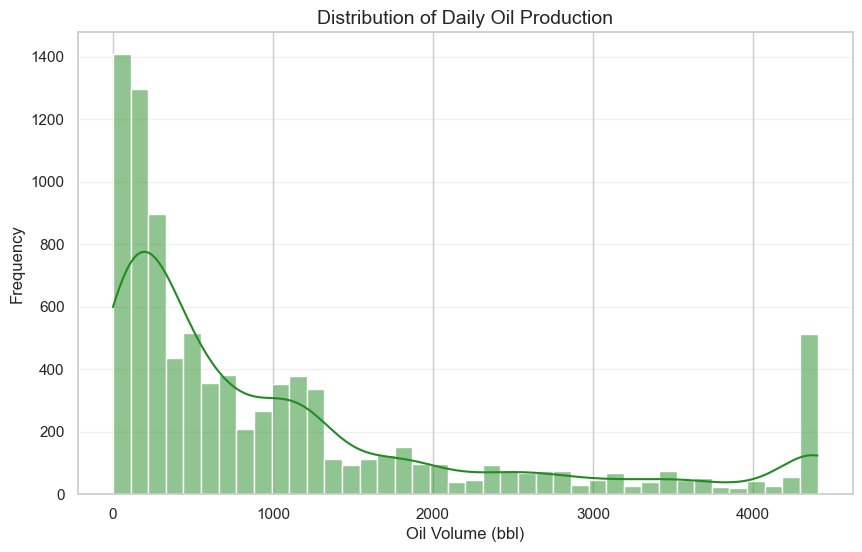

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['BORE_OIL_VOL'], kde=True, color='forestgreen')

plt.title('Distribution of Daily Oil Production', fontsize=14)
plt.xlabel('Oil Volume (bbl)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

## ### 📈 2. Cross-Plot: Pressure vs. Oil Production
## ### * Objective:**
* To investigate the relationship between Average Downhole Pressure and Oil Flow Rates.
* This scatter plot helps identify the pressure-drive mechanism of the reservoir.
* It is a vital diagnostic tool for predicting well performance based on pressure trends.

In [37]:
df=df.reset_index(drop=True)

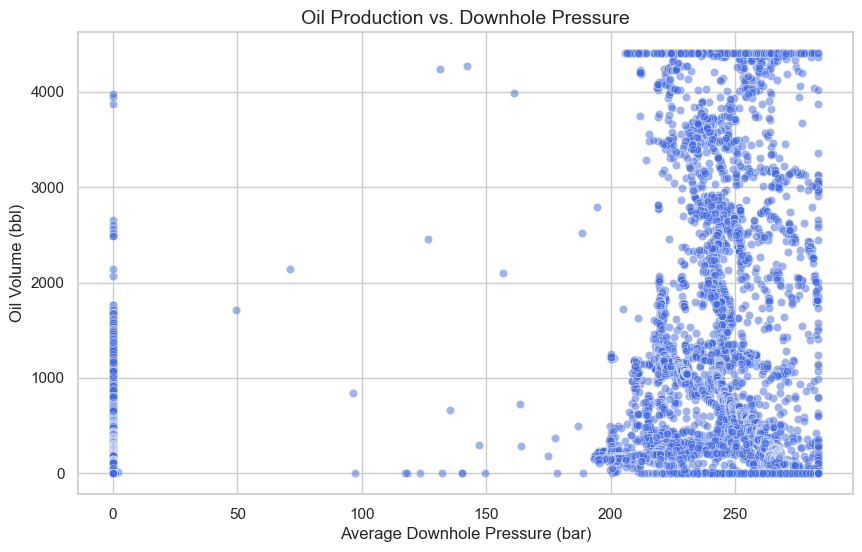

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AVG_DOWNHOLE_PRESSURE', y='BORE_OIL_VOL', alpha=0.5, color='royalblue')

plt.title('Oil Production vs. Downhole Pressure', fontsize=14)
plt.xlabel('Average Downhole Pressure (bar)', fontsize=12)
plt.ylabel('Oil Volume (bbl)', fontsize=12)
plt.show()

## ### 🌡️ 3. Multi-Variable Correlation Analysis
## ### * Objective:**
* To quantify the linear relationship between all numerical variables in the dataset.
* This heatmap highlights which parameters (Temperature, Pressure, etc.) have the highest impact on Oil Volume.
* High correlation coefficients (near 1 or -1) indicate strong predictive relationships.

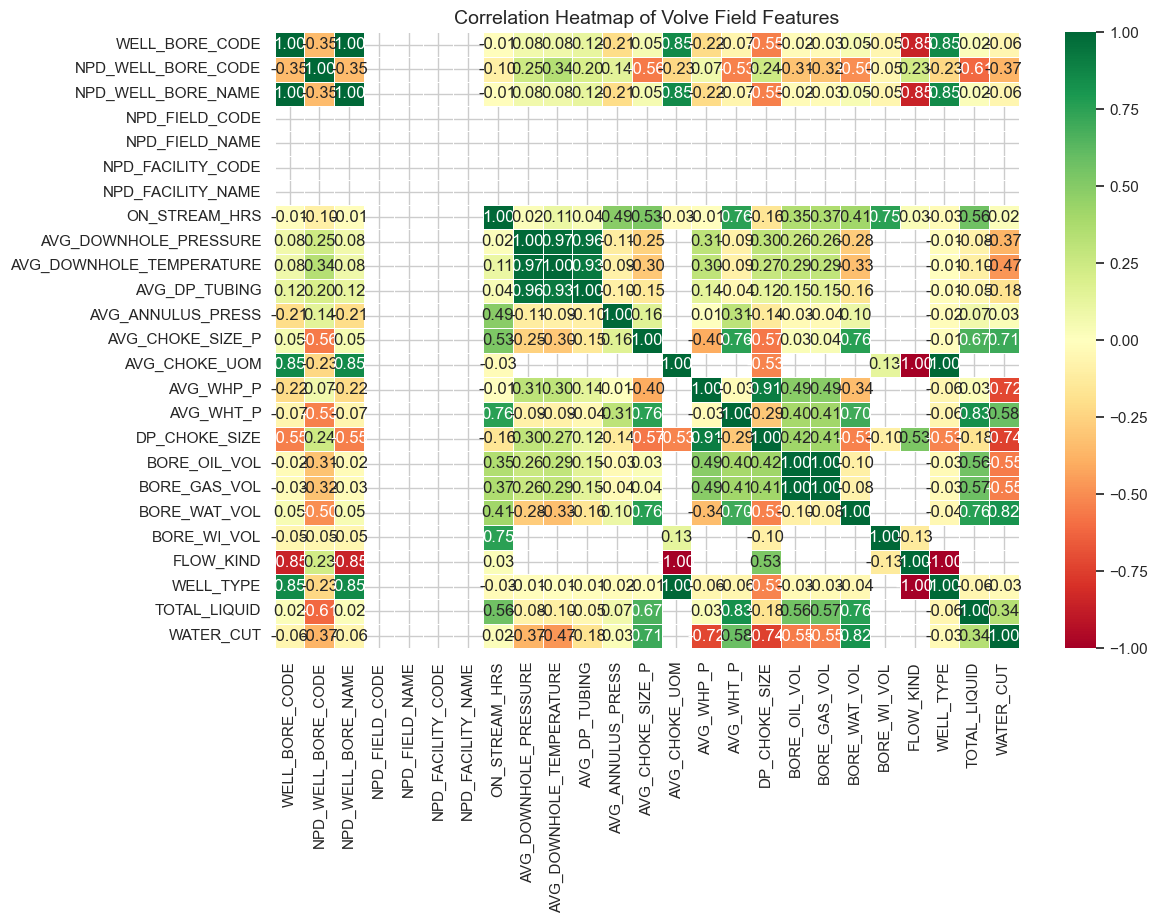

In [35]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Volve Field Features', fontsize=14)
plt.show()

This heatmap shows relationships between numerical variables.

## ### 📦 4. Comparative Analysis: Well-by-Well Pressure
## ### * Objective:**
* To compare the pressure stability and ranges across different wellbores.
* The Box Plot effectively displays the median, quartiles, and range for each specific well.
* This helps engineers identify high-performing vs. low-performing wells in the field.

This section shows distributions of numerical features.

C:\Users\Al SaaD GrouP\AppData\Local\Temp\ipykernel_17008\2967444889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NPD_WELL_BORE_NAME', y='AVG_DOWNHOLE_PRESSURE', palette='Set2')


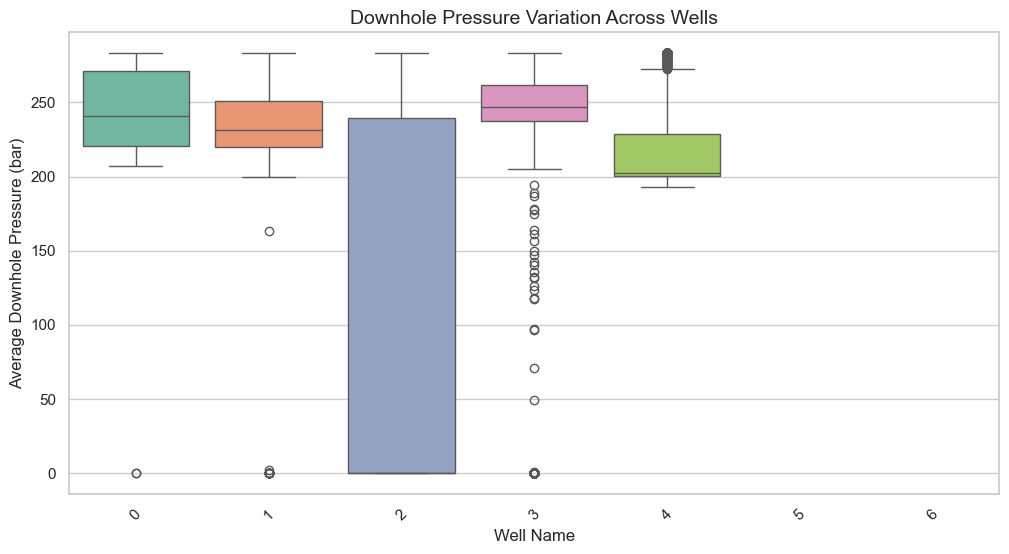

In [39]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NPD_WELL_BORE_NAME', y='AVG_DOWNHOLE_PRESSURE', palette='Set2')

plt.title('Downhole Pressure Variation Across Wells', fontsize=14)
plt.xlabel('Well Name', fontsize=12)
plt.ylabel('Average Downhole Pressure (bar)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## ### 📉 5. Production Lifecycle & Timeline
## ### * Objective:**
* To plot the total oil production over the entire timeframe of the dataset.
* This represents the Production Profile, showing the build-up, plateau, and decline phases.
* It is essential for field management and estimating the ultimate recovery of the reservoir.

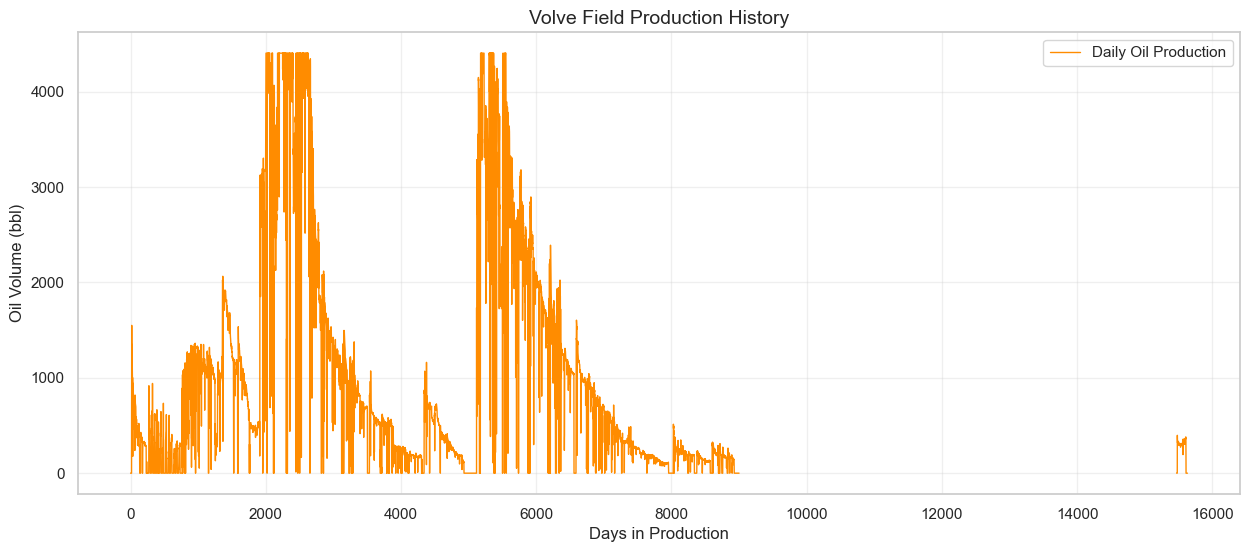

In [40]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['BORE_OIL_VOL'], color='darkorange', linewidth=1, label='Daily Oil Production')

plt.title('Volve Field Production History', fontsize=14)
plt.xlabel('Days in Production', fontsize=12)
plt.ylabel('Oil Volume (bbl)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
df.to_csv("final_clean_data.csv", index=False)

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Configuration of the Streamlit Dashboard Layout
st.set_page_config(page_title="Petroleum Production Analytics", layout="wide")

st.title("🛢️ Volve Field Production Analytics Dashboard")
st.markdown("---")

# Data Loading with Caching for Performance
@st.cache_data
def load_processed_data():
    data = pd.read_csv("D:\\mid-proj\\final_clean_data.csv")
    data['DATEPRD'] = pd.to_datetime(data['DATEPRD'])
    return data

df = load_processed_data()

# Sidebar: Dynamic Filtering Mechanism
st.sidebar.header("Navigation & Filters")
well_selection = st.sidebar.selectbox("Select Target Wellbore", df['NPD_WELL_BORE_NAME'].unique())

# Filter dataset based on user selection
filtered_df = df[df['NPD_WELL_BORE_NAME'] == well_selection]

# Key Performance Indicators (KPIs) Calculation
col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Cumulative Oil (bbl)", f"{filtered_df['BORE_OIL_VOL'].sum():,.0f}")
with col2:
    st.metric("Avg Pressure (psi)", f"{filtered_df['AVG_DOWNHOLE_PRESSURE'].mean():.2f}")
with col3:
    st.metric("Well Count", len(df['NPD_WELL_BORE_NAME'].unique()))

# Interactive Plots
st.subheader(f"Detailed Analysis for Well: {well_selection}")
fig_trend = px.area(filtered_df, x='DATEPRD', y='BORE_OIL_VOL', title="Production Decline Curve")
st.plotly_chart(fig_trend, use_container_width=True)

2026-04-10 01:50:52.713 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 01:50:52.716 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 01:50:53.895 
  command:

    streamlit run c:\Users\Al SaaD GrouP\volve_env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-10 01:50:53.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 01:50:53.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 01:50:53.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 01:50:53.905 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored w

DeltaGenerator()

# 📊 Project Insights & Conclusion

---

### 🔍 Key Insights
* 🎯 Strong Physical Correlation: The data analysis reveals a significant positive correlation between downhole pressure and oil flow rates. This confirms that maintaining reservoir energy is the primary driver for production in the Volve field.

* 🛢️ Well Performance Variability: By comparing different wellbores, we identified that Well F-14 maintained the most stable production profile, while other wells showed faster decline rates, indicating areas for potential artificial lift optimization.

* 🧹 Data Quality Impact: The initial data exploration and outlier removal were critical. Identifying sensor errors ensured that our production decline curves reflect actual field behavior rather than measurement noise.

---

### 💡 Final Conclusion
This project demonstrates the powerful synergy between Petroleum Engineering expertise and Data Science tools. By transforming raw, unstructured production data into an interactive visual dashboard, we have created a decision-support system that allows engineers to monitor field performance accurately and efficiently. 

This "Digital Oilfield" approach is essential for modern reservoir management, enabling data-driven decisions that maximize recovery and minimize operational risks.